<a href="https://colab.research.google.com/github/Swaswasti/Food-Delivery-Cost-Prediction/blob/main/Food_Delivery_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Cost Prediction using Machine Learning


## 1. Introduction

Food delivery services need to calculate delivery charges accurately.
This project predicts food delivery cost based on distance, delivery time,
order value, number of items, and peak hours using Machine Learning.


## 2. Problem Statement

The goal of this project is to build a machine learning model that predicts
the delivery cost of food orders using various input features.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


## 3. Dataset Creation

A synthetic dataset of 1000 food delivery orders is created using Python.
This approach is useful when real-world data is unavailable.


In [8]:
np.random.seed(42)

rows = 1000

data = {
    'distance_km': np.random.randint(1, 20, rows),
    'delivery_time_min': np.random.randint(10, 60, rows),
    'order_value': np.random.randint(100, 1500, rows),
    'num_items': np.random.randint(1, 10, rows),
    'peak_hour': np.random.randint(0, 2, rows)
}

df = pd.DataFrame(data)

# Create delivery cost logically
df['delivery_cost'] = (
    df['distance_km'] * 5 +
    df['delivery_time_min'] * 1.5 +
    df['num_items'] * 10 +
    df['peak_hour'] * 20
)
df.head(30)

,distance_km,delivery_time_min,order_value,num_items,peak_hour,delivery_cost
0,7,19,764,1,1,93.5
1,15,28,111,3,1,167.0
2,11,55,1256,2,0,157.5
3,8,43,403,5,1,174.5
4,7,42,1416,5,1,168.0
5,19,32,1074,5,0,193.0
6,11,37,1423,4,1,170.5
7,11,41,882,5,0,166.5
8,4,59,142,3,0,138.5
9,8,16,1043,1,0,74.0


## 4. Data Understanding


In [7]:
df.shape

(1000, 6)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distance_km        1000 non-null   int64  
 1   delivery_time_min  1000 non-null   int64  
 2   order_value        1000 non-null   int64  
 3   num_items          1000 non-null   int64  
 4   peak_hour          1000 non-null   int64  
 5   delivery_cost      1000 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [10]:
df.describe()

,distance_km,delivery_time_min,order_value,num_items,peak_hour,delivery_cost
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,9.746000,34.798000,782.32900,4.93800,0.497000,160.247000
std,5.651497,14.364175,389.58468,2.60556,0.500241,44.706506
min,1.000000,10.000000,100.00000,1.00000,0.000000,35.000000
25%,5.000000,22.000000,454.50000,3.00000,0.000000,126.500000
50%,9.000000,35.000000,761.00000,5.00000,0.000000,160.000000
75%,15.000000,47.000000,1109.25000,7.00000,1.000000,192.500000
max,19.000000,59.000000,1499.00000,9.00000,1.000000,283.500000


## 5. Exploratory Data Analysis


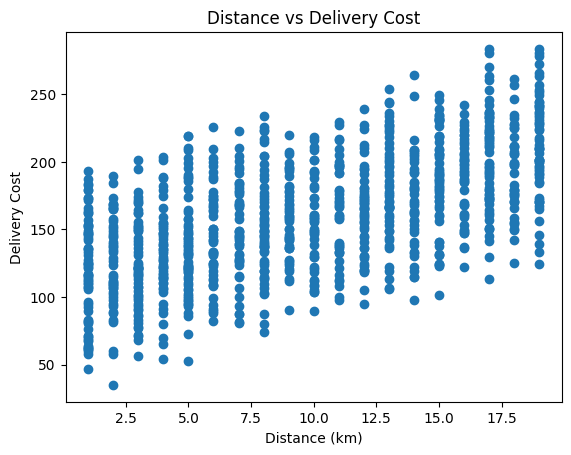

In [11]:
plt.figure()
plt.scatter(df['distance_km'], df['delivery_cost'])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")
plt.title("Distance vs Delivery Cost")
plt.show()


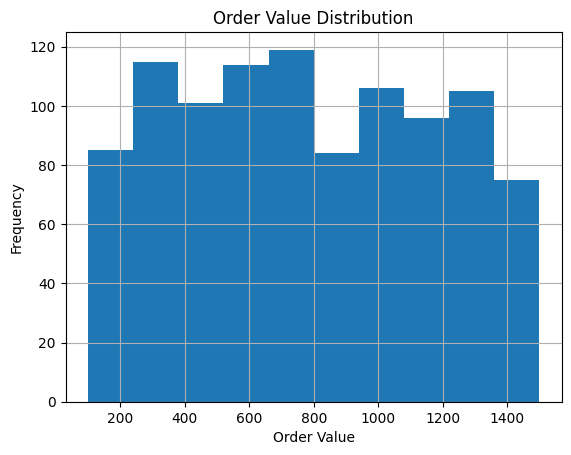

In [12]:
plt.figure()
df['order_value'].hist()
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.title("Order Value Distribution")
plt.show()


## 6. Feature Selection

The dataset is divided into independent variables (X) and target variable (y).


In [13]:
X = df[['distance_km', 'delivery_time_min', 'order_value', 'num_items', 'peak_hour']]
y = df['delivery_cost']


## 7. Train-Test Split

The data is split into training and testing sets.
Training data teaches the model, while testing data checks accuracy.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## 8. Model Training

Linear Regression is used to train the model.


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## 9. Model Evaluation

The model performance is evaluated using Mean Absolute Error.


In [16]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)


Mean Absolute Error: 2.310684976691846e-13


## 10. Prediction


In [17]:
new_order = [[8, 35, 600, 4, 1]]
predicted_cost = model.predict(new_order)

print("Predicted Delivery Cost:", predicted_cost[0])


Predicted Delivery Cost: 152.50000000000009


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
